# Block 2.1 tutorial: two generative models, one toy dataset

Full instructions are on the slides. Most of the code here is already written: your job is not to
write a model, it is to run the code and **check** that it does what it claims.

Six things to do, marked **TODO** in the cells below. Three of them ask you to type a line or two,
and the rest ask you to run a cell and read what comes back:

1. TODO 1: run the set-up cell.
2. TODO 2: make the data and look at it.
3. TODO 3: print the shape and the value range, and say whether the data is what you think it is.
4. TODO 4: train both conditions, and check the loss is actually falling.
5. TODO 5: generate the samples, from both trained models.
6. TODO 6: draw a different sixteen by changing one number.

Then one short write-up at the end.

Run every cell from the top, one at a time: click a cell, press Shift+Enter, wait for the output to
appear underneath. Nothing here needs a GPU, and both models together train in well under a minute.

There are worked answers for every TODO in the tutorial solutions, posted on Canvas after the
block. Try each one before you look.


## Setting up

**TODO 1: run the next cell.** Nothing to write here, but nothing below works until it has run.

It loads what the notebook uses: `numpy` for arrays of numbers, `torch` for the neural network,
`matplotlib` for the pictures, `time` for measuring how long training takes, and `datasets.py`, the
file sitting next to this notebook, for the images themselves. From `pythae` it takes the model, the
training pipeline, a sampler and the training settings.

It then fixes the random seeds, so a re-run starts from the same random numbers, and sets the image
size to 8 by 8 pixels.

If it fails with `ModuleNotFoundError: No module named 'datasets'`, the notebook is not running from
the folder that holds `datasets.py`. Put the two files side by side and start the notebook again.


In [1]:
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

from pythae.models import VAE, VAEConfig
from pythae.pipelines import TrainingPipeline
from pythae.samplers import NormalSampler
from pythae.trainers import BaseTrainerConfig

np.random.seed(0)
torch.manual_seed(0)
SIZE = 28  # 28x28 MNIST digits

/Users/youssefhaddouch/.cache/uv/archive-v0/6JVm7sA8R-U66hgb/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Look at the data

`make_bars_and_stripes` builds small binary images: every image is either all horizontal bars or all
vertical stripes, each line switched on independently. No download, no external dataset, generated
in code.

**TODO 2: run the next cell.** It makes 2,000 training images and 200 evaluation images, reshapes
them into the (images, channels, height, width) layout `pythae` expects, and draws the first sixteen.
Look at the picture before moving on: every image should be bars or stripes, and never both.


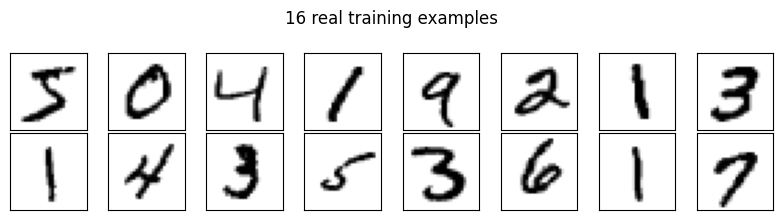

In [5]:
from torchvision.datasets import MNIST

mnist_train = MNIST(root="data", train=True, download=True)
mnist_test = MNIST(root="data", train=False, download=True)

# Pixels come as 0-255 integers; scale to 0.0-1.0 and add the channel dimension
train_data = (mnist_train.data.numpy() / 255.0).astype("float32").reshape(-1, 1, SIZE, SIZE)
eval_data = (mnist_test.data.numpy() / 255.0).astype("float32").reshape(-1, 1, SIZE, SIZE)

fig, axes = plt.subplots(2, 8, figsize=(8, 2.2))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_data[i, 0], cmap="gray_r", vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("16 real training examples")
fig.tight_layout()
plt.show()

**Check 1: is the data what you think it is?**

**TODO 3: print the shape and the value range yourself.** This is the check that catches a
data-loading mistake before you waste a training run on it, and it is three lines.

In the next cell, print:

1. `train_data.shape`, the shape of the array: how many images, how many colour channels, and how
   many pixels each way. Any array has a `.shape`, so `train_data.shape` is the whole answer.
2. The lowest and the highest value in it, with `train_data.min()` and `train_data.max()`.
3. Every distinct value it contains, with `np.unique(train_data)`.

`print("some label:", the_value)` prints a label and a value together, which is what makes output
readable later.

**What you should see.** 2,000 images of 8 by 8 pixels with one channel, so a shape of
`(2000, 1, 8, 8)`, and only `0.0` and `1.0`, so binary rather than greyscale. Do the same three
checks on any dataset you load for Subelement 1, before you train anything on it.


In [6]:
# TODO 3: print the shape, the value range, and the distinct values of train_data.
# Expect (2000, 1, 8, 8), a range of 0.0 to 1.0, and only two distinct values.

print("train_data shape:", train_data.shape)
print("value range:", train_data.min(), "to", train_data.max())
print("unique values:", np.unique(train_data))

train_data shape: (60000, 1, 28, 28)
value range: 0.0 to 1.0
unique values: [0.         0.00392157 0.00784314 0.01176471 0.01568628 0.01960784
 0.02352941 0.02745098 0.03137255 0.03529412 0.03921569 0.04313726
 0.04705882 0.05098039 0.05490196 0.05882353 0.0627451  0.06666667
 0.07058824 0.07450981 0.07843138 0.08235294 0.08627451 0.09019608
 0.09411765 0.09803922 0.10196079 0.10588235 0.10980392 0.11372549
 0.11764706 0.12156863 0.1254902  0.12941177 0.13333334 0.13725491
 0.14117648 0.14509805 0.14901961 0.15294118 0.15686275 0.16078432
 0.16470589 0.16862746 0.17254902 0.1764706  0.18039216 0.18431373
 0.1882353  0.19215687 0.19607843 0.2        0.20392157 0.20784314
 0.21176471 0.21568628 0.21960784 0.22352941 0.22745098 0.23137255
 0.23529412 0.23921569 0.24313726 0.24705882 0.2509804  0.25490198
 0.25882354 0.2627451  0.26666668 0.27058825 0.27450982 0.2784314
 0.28235295 0.28627452 0.2901961  0.29411766 0.29803923 0.3019608
 0.30588236 0.30980393 0.3137255  0.31764707 0.32156864

## 2. Train two conditions, fairly

A fair comparison changes exactly one thing. Here it is `latent_dim`, the size of the small vector
each image is squeezed into before being decoded back out. Same data, same number of epochs, same
optimiser and same architecture either side. If the samples come out different, that difference is
the one thing we changed, not a data artefact or a lucky training run.

**TODO 4: run the next cell, then read Check 2 underneath it.** This one is written for you, and it
is the cell worth reading line by line before you run it.

It defines `train_condition`, which builds a VAE with a given `latent_dim`, sets the training options
(150 epochs, batches of 64 images, learning rate 0.001, CPU only), runs the training loop and returns
the trained model. It then calls it twice, with 2 and with 16, and times both calls.

`pythae` prints a running log while it trains, and saves each trained model into a `runs/` folder
next to this notebook. The log comes out on a pink background: that is `pythae` writing progress to
the error stream, not an error.


In [7]:
def train_condition(latent_dim, epochs=150):
    config = VAEConfig(input_dim=(1, SIZE, SIZE), latent_dim=latent_dim, reconstruction_loss="bce")
    model = VAE(config)
    trainer_config = BaseTrainerConfig(
        output_dir=f"runs/latent_{latent_dim}",
        num_epochs=epochs,
        learning_rate=1e-3,
        per_device_train_batch_size=64,
        per_device_eval_batch_size=64,
        steps_saving=None,
        no_cuda=True,
    )
    pipeline = TrainingPipeline(model=model, training_config=trainer_config)
    pipeline(train_data=train_data, eval_data=eval_data)
    return model

started = time.perf_counter()
model_b = train_condition(latent_dim=16, epochs=50)   # one MNIST run: latent_dim=16, 20 epochs
finished = time.perf_counter()

print(f"latent_dim=16 on MNIST trained in {finished - started:.1f}s")

Preprocessing train data...
Checking train dataset...
Preprocessing eval data...

Checking eval dataset...
Using Base Trainer

Model passed sanity check !
Ready for training.

Created runs/latent_16/VAE_training_2026-09-26_14-00-15. 
Training config, checkpoints and final model will be saved here.

Training params:
 - max_epochs: 50
 - per_device_train_batch_size: 64
 - per_device_eval_batch_size: 64
 - checkpoint saving every: None
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Scheduler: None

Successfully launched training !

Eval of epoch 1/50: 100%|█████████████████████████████████████| 157/157 [00:00<00:00, 1255.89batch/s]
--------------------------------------------------------------------------
Train loss: 142.3219
Eval loss: 116.5361
----------------------------

latent_dim=16 on MNIST trained in 110.7s


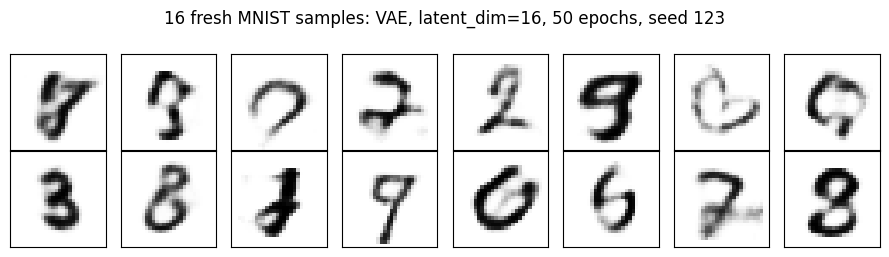

In [8]:
SEED = 123
torch.manual_seed(SEED)
sixteen = NormalSampler(model_b).sample(num_samples=16, batch_size=16).detach().numpy()[:, 0]

fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for ax, image in zip(axes.flat, sixteen):
    ax.imshow(image, cmap="gray_r", vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"16 fresh MNIST samples: VAE, latent_dim=16, 50 epochs, seed {SEED}")
fig.tight_layout()
fig.savefig("mnist_samples_latent16.png", dpi=150)
plt.show()

**Check 2: is training actually running?** Scroll up through the log the cell just printed.
`Train loss` and `Eval loss` should fall across epochs, not sit flat. A loss that is flat from the
first epoch means nothing is learning, whatever the samples look like afterwards.

Write down the first and the last `Train loss` you can see, for each condition. You need those two
numbers for the write-up at the end, and "the loss fell from 44.0 to 14.7" is a sentence a marker can
check, where "training worked" is not.


## 3. Sample from both conditions, side by side

Sampling means drawing a fresh random vector and decoding it. No training image goes anywhere near
this step.

**TODO 5: generate the samples yourself.** The plotting is written for you; the two lines that
actually produce the output are not.

A `NormalSampler` wraps a trained model and draws fresh samples from it. `sampler_a` and
`sampler_b` are already built for you, one per condition. Each has a `.sample` method:

```python
sampler_a.sample(num_samples=8, batch_size=8)
```

That hands back a `torch` tensor of 8 images, shaped (8, 1, 8, 8). Two more steps turn it into
something `matplotlib` can draw: `.detach().numpy()` converts it to a plain numpy array, and
`[:, 0]` drops the colour-channel dimension, leaving 8 images of 8 by 8.

Fill in `samples_a` and `samples_b` in the next cell, one per condition, 8 samples each.

**What you should see.** Two rows of eight small images: `latent_dim=2` on top, `latent_dim=16`
underneath. They will not look identical to anyone else's if your machine differs, but the shape of
the difference should hold.


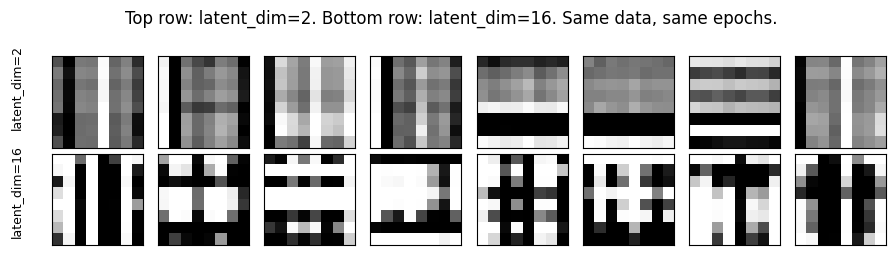

In [6]:
torch.manual_seed(123)
sampler_a, sampler_b = NormalSampler(model_a), NormalSampler(model_b)

# TODO 5: draw 8 fresh samples from each sampler, as numpy arrays without the channel dimension.
# Pattern: sampler.sample(num_samples=8, batch_size=8).detach().numpy()[:, 0]
samples_a = sampler_a.sample(num_samples=8, batch_size=8).detach().numpy()[:, 0]
samples_b = sampler_b.sample(num_samples=8, batch_size=8).detach().numpy()[:, 0]

fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for i in range(8):
    axes[0, i].imshow(samples_a[i], cmap="gray_r", vmin=0, vmax=1)
    axes[1, i].imshow(samples_b[i], cmap="gray_r", vmin=0, vmax=1)
    for ax in (axes[0, i], axes[1, i]):
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Top row: latent_dim=2. Bottom row: latent_dim=16. Same data, same epochs.")
fig.text(0.01, 0.68, "latent_dim=2", fontsize=9, rotation=90, va="center")
fig.text(0.01, 0.28, "latent_dim=16", fontsize=9, rotation=90, va="center")
fig.tight_layout(rect=(0.04, 0, 1, 1))
plt.show()

## 4. Samples, or reconstructions?

**Check 3: which of the two are you looking at?** They are easy to mix up. A **reconstruction**
encodes a real image and decodes what comes back, so the model has seen that image. A **sample**
decodes a fresh random vector that never touched the encoder, so it has seen nothing. Confirm which
one you have before you compare anything.

The next cell takes one real training image, reconstructs it, draws one fresh sample, and puts the
three side by side.

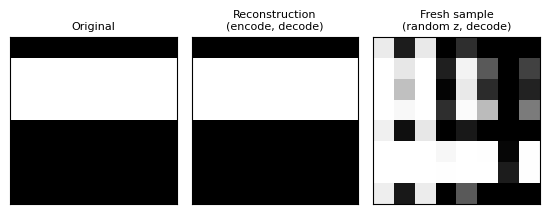

In [7]:
torch.manual_seed(7)
idx = 3
x = torch.tensor(train_data[idx : idx + 1])
with torch.no_grad():
    z_recon = model_b.encoder(x).embedding
    recon = model_b.decoder(z_recon)["reconstruction"].numpy()[0, 0]
fresh = sampler_b.sample(num_samples=1, batch_size=1)[0, 0].detach().numpy()

fig, axes = plt.subplots(1, 3, figsize=(5.6, 2.1))
titles = ["Original", "Reconstruction\n(encode, decode)", "Fresh sample\n(random z, decode)"]
for ax, im, t in zip(axes, [train_data[idx, 0], recon, fresh], titles):
    ax.imshow(im, cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(t, fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

## 5. The copy check

A model could pass every check so far by memorising the training set and handing pieces of it back.
**The copy check** measures how far an image is from its closest real training image, counted in
pixels: 0.0 means an exact copy, and 8.0 is the furthest two 8 by 8 images can be from each other.

The next cell runs it twice, on the reconstruction and on the fresh sample, and shows the sample
next to the training image it came closest to. The reconstruction should land near 0.0, because it
was built from that image. The sample should not.

reconstruction, to the image it was built from: 0.00 pixels
fresh sample, to its nearest training image:    3.39 pixels
(0.00 is an exact copy, 8.00 is as far apart as two of these images get)


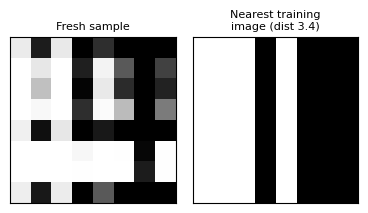

In [8]:
recon_dist = float(np.sqrt(np.sum((train_data[idx, 0] - recon) ** 2)))

dists = np.sum((train_data[:, 0] - fresh[None]) ** 2, axis=(1, 2))
nn_idx = int(np.argmin(dists))
nn_dist = float(np.sqrt(dists[nn_idx]))

print(f"reconstruction, to the image it was built from: {recon_dist:.2f} pixels")
print(f"fresh sample, to its nearest training image:    {nn_dist:.2f} pixels")
print(f"(0.00 is an exact copy, {SIZE:.2f} is as far apart as two of these images get)")

fig, axes = plt.subplots(1, 2, figsize=(3.8, 2.1))
titles = ["Fresh sample", f"Nearest training\nimage (dist {nn_dist:.1f})"]
for ax, im, t in zip(axes, [fresh, train_data[nn_idx, 0]], titles):
    ax.imshow(im, cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(t, fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

## 6. Your turn: a different sixteen

**TODO 6: change one number, three times.** `SEED` fixes the random numbers the samples are drawn
from, and it is the only thing you have to change.

1. Run the cell as it is.
2. Change `SEED` to any other whole number and run it again. A different sixteen come out.
3. Set `SEED` back to 123 and run it a third time. The first sixteen come back, exactly.

Step 3 is the point: a fixed seed is what makes a result reproducible, by you and by whoever reads
your work. A figure in your portfolio that nobody can regenerate is worth less than one that anyone
can.

Swap `MODEL` from `model_b` to `model_a` for the same sixteen from the `latent_dim=2` condition
instead.


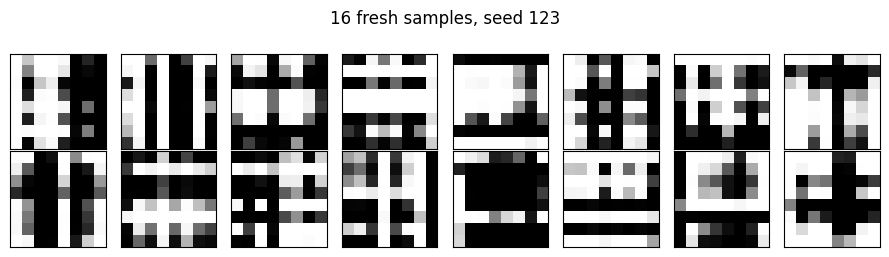

In [12]:
# TODO 6: run this, change SEED, run it again, then set SEED back to 123 and run it once more.
SEED = 123
MODEL = model_b  # model_b is latent_dim=16, model_a is latent_dim=2

torch.manual_seed(SEED)
sixteen = NormalSampler(MODEL).sample(num_samples=16, batch_size=16).detach().numpy()[:, 0]

fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for ax, image in zip(axes.flat, sixteen):
    ax.imshow(image, cmap="gray_r", vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"16 fresh samples, seed {SEED}")
fig.tight_layout()
plt.show()

## Your task: describe the difference

Look at the two rows of samples in section 3, all eight of each rather than the first one. Write two
or three honest sentences on how `latent_dim=2` differs from `latent_dim=16`. Describe what is
actually there (blur, a faint second orientation, clean bars) rather than what you expected to see.

Then run section 6 again at a different seed and check your sentences still fit that sixteen too.

There is a worked example of this description in the tutorial solutions, released after the block.
Write your own first.


With everything else held fixed, latent_dim=2 finished at a loss of about 26 against 14.7 for latent_dim=16, and its samples were blurry and mostly grey, although almost every one still leaned clearly towards either bars or stripes. latent_dim=16 got rid of the blur, but across two seeds (6 and 123) most of its samples mixed bars and stripes into grid shapes that never appear in the training data, so sharper didn't mean more correct. The copy check put a fresh sample 3.39 pixels from its nearest training image (a reconstruction scored 0.00), so the model is drawing new images rather than handing back ones it was trained on.